# Spectral Gaussian Processes  
**Next‐project pitch**  
*Meeting: Monday, May 19, 2025*

---

## 1. Recap: “Circulant BNN Layer”  
- **Goal**: Bayesian linear map $z = W x + b$ with  
  $$
    W = F^{-1}\,\mathrm{diag}(\hat w)\,F,
    \quad \hat w_k \sim \mathcal N(0,\,\sigma_k^2).
  $$ 
- **Implementation**:  
  - JAX + NumPyro  
  - $\texttt{@custom\_jvp}$ FFT matmul for forward/backward  
  - Samples a length-$n$ Gaussian *vector* per input  
- **Key takeaway**: FFT makes weight sampling $\mathcal{O}(n\log n)$, but this is still a ººBayesian neural layerºº, not a GP over arbitrary inputs.

---

## 2. Why an *Exact* GP?  
- A true GP gives a **covariance kernel** $k(x,x')$ for *any* two inputs.  
- We’d like:  
  1. **Expressive**: learn *any* stationary spectrum  
  2. **Scalable**: $\mathcal{O}(N\log N)$ inference on $N$ equally spaced points  
  3. **Theoretical**: RKHS, generalization, marginal-likelihood  

---

## 3. Spectral–Circulant Kernel Construction  
1. **Parameterize** nonnegative spectrum on grid of size $N$:  
  $$
     \theta_\ell \sim \mathcal N(0,1),
     \quad
     F_\ell = \log\bigl(1 + e^{\theta_\ell}\bigr)
     \quad (\ge0).
  $$
2. **Form** circulant covariance via inverse FFT:  
  $$
     k_0 = \tfrac1N\,\mathrm{IFFT}(F), 
     \quad
     K = \mathrm{circ}(k_0).
  $$
3. **Inference**: diagonalize with FFT  
  $$
     K + \sigma^2 I = F^{-1}\,\mathrm{diag}(F + \sigma^2)\,F
     \;\;\Longrightarrow\;\;
     \mathcal{O}(N\log N)\ \text{solve \& logdet.}
  $$

---

## 4. Why This Matters  
- **True GP**:  
  $$
    f \sim \mathcal{GP}\bigl(0,\,k(\cdot,\cdot)\bigr),
    \quad
    k(x_i,x_j) = [\,\mathrm{circ}(\mathrm{IFFT}(F))\,]_{ij}.
  $$
- **Kernel methods**: plug $K$ into  
  - GaussianProcessRegressor (scikit-learn)  
  - SVM / sparse SVM dual  
- **Theory + Practice**:  
  - RKHS norm $\|f\|^2_{\mathcal H}=\sum |\hat f_\ell|^2/F_\ell$ 
  - Generalisation rates via spectral decay  
  - Empirical gains vs. RBF, SM, RFF  

---

## 5. Proposed Plan & Next Steps  
1. **Demo** in notebook:  
   - Prior samples, regression vs. RBF  
   - NUTS fit + posterior predictive  
2. **Write-up outline**:  
   - Intro & related work  
   - Kernel construction & theory  
   - Inference algorithms & complexity  
   - Experiments (UCI benchmarks, scalability)  
3. **Timeline**:  
   - This week: finalize code + slides  
   - Next week: draft paper & internal review  

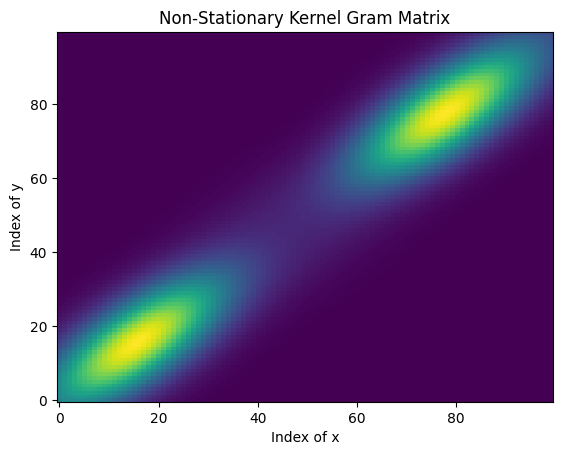

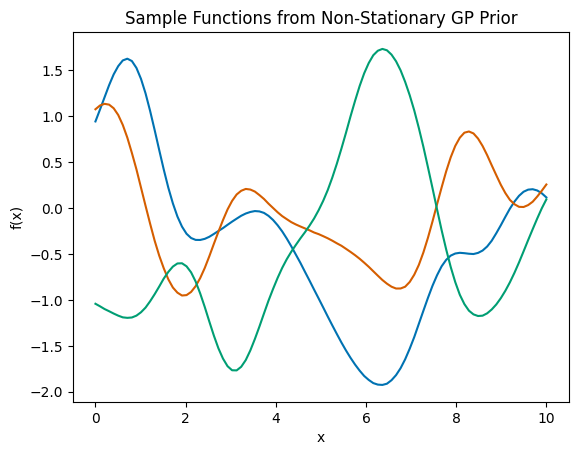

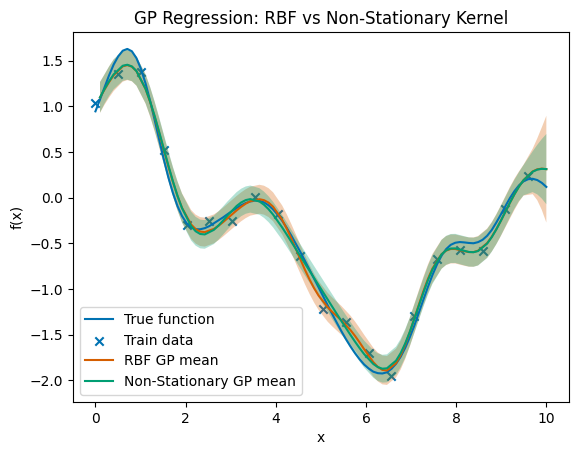

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Kernel as BaseKernel, RBF

# Use a colorblind‐friendly palette: Tableau 10
plt.rcParams['axes.prop_cycle'] = plt.cycler(
    'color',
    ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#F0E442', '#56B4E9', '#E69F00', '#000000']
)

# 1. Define the custom non-stationary kernel
class NonStationaryKernel(BaseKernel):
    def __init__(self, length_scale=1.0):
        self.length_scale = length_scale

    def __call__(self, X, Y=None, eval_gradient=False):
        if Y is None:
            Y = X
        X = np.atleast_2d(X).ravel()
        Y = np.atleast_2d(Y).ravel()
        sigma_X = 1 + 0.5 * np.sin(X)
        sigma_Y = 1 + 0.5 * np.sin(Y)
        d2 = (X[:, None] - Y[None, :]) ** 2
        K = np.outer(sigma_X, sigma_Y) * np.exp(-d2 / (2 * self.length_scale**2))
        if eval_gradient:
            # gradient w.r.t. length_scale
            grad = K * d2 / (self.length_scale**3)
            return K, grad[..., None]
        return K

    def diag(self, X):
        X = np.atleast_2d(X).ravel()
        return (1 + 0.5 * np.sin(X))**2

    def is_stationary(self):
        return False

# 2. Prepare data
x = np.linspace(0, 10, 100)
x = x.reshape(-1, 1)

# 3. Plot Gram matrix
kernel_ns = NonStationaryKernel(length_scale=1.0)
K = kernel_ns(x)
plt.figure()
plt.imshow(K, origin='lower', aspect='auto')
plt.title("Non-Stationary Kernel Gram Matrix")
plt.xlabel("Index of x")
plt.ylabel("Index of y")
plt.show()

# 4. Sample functions from the GP prior
L = np.linalg.cholesky(K + 1e-6 * np.eye(len(K)))
samples = L @ np.random.randn(len(K), 3)
plt.figure()
for i in range(3):
    plt.plot(x.ravel(), samples[:, i])
plt.title("Sample Functions from Non-Stationary GP Prior")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

# 5. Regression experiment
# True function: a sample from the same GP plus noise
f_true = samples[:, 0]
y = f_true + 0.1 * np.random.randn(len(f_true))

# Split train/test
idx = np.arange(len(x))
train_idx = idx[::5]
test_idx = np.setdiff1d(idx, train_idx)
X_train, y_train = x[train_idx], y[train_idx]
X_test, y_test = x[test_idx], f_true[test_idx]

# Fit RBF kernel GP
gp_rbf = GaussianProcessRegressor(kernel=RBF(length_scale=1.0), alpha=0.01)
gp_rbf.fit(X_train, y_train)
y_pred_rbf, std_rbf = gp_rbf.predict(X_test, return_std=True)

# Fit Non-Stationary kernel GP
gp_ns = GaussianProcessRegressor(kernel=kernel_ns, alpha=0.01)
gp_ns.fit(X_train, y_train)
y_pred_ns, std_ns = gp_ns.predict(X_test, return_std=True)

# 6. Plot predictions
plt.figure()
plt.plot(x, f_true, label="True function")
plt.scatter(X_train, y_train, label="Train data", marker='x')
plt.plot(X_test, y_pred_rbf, label="RBF GP mean")
plt.fill_between(X_test.ravel(), y_pred_rbf - 2*std_rbf, y_pred_rbf + 2*std_rbf, alpha=0.3)
plt.plot(X_test, y_pred_ns, label="Non-Stationary GP mean")
plt.fill_between(X_test.ravel(), y_pred_ns - 2*std_ns, y_pred_ns + 2*std_ns, alpha=0.3)
plt.legend()
plt.title("GP Regression: RBF vs Non-Stationary Kernel")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()


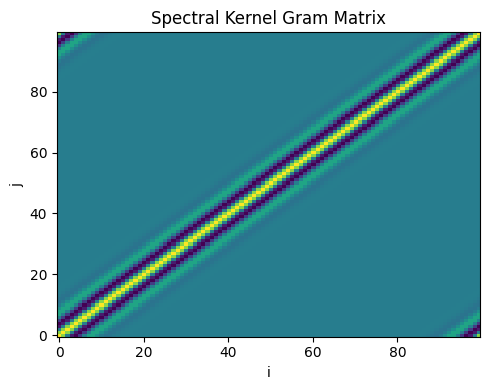

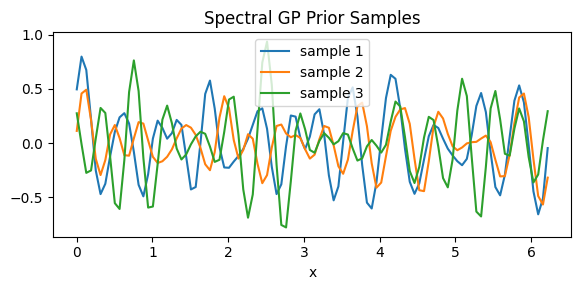

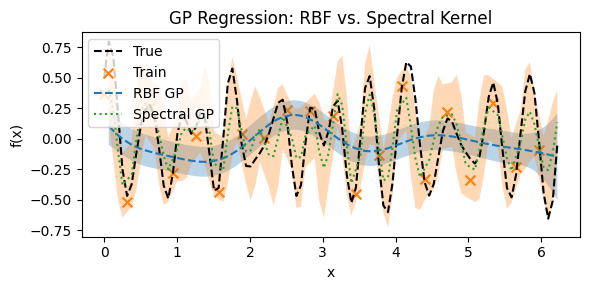

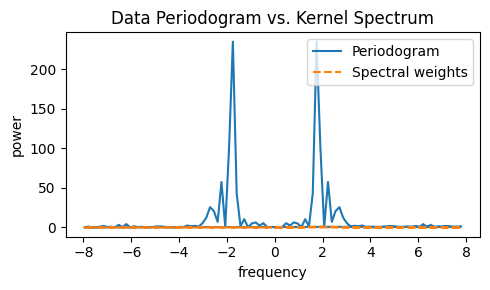

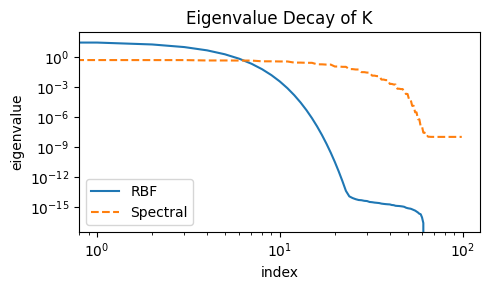

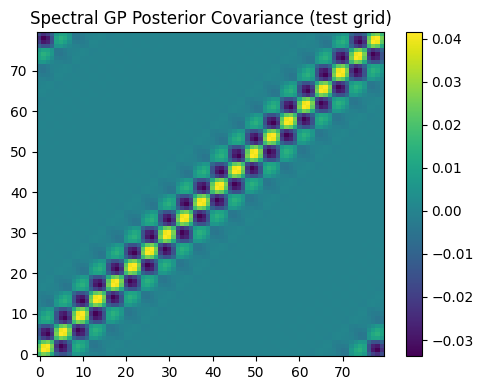

/var/folders/ch/74rww8ps6cx8x_ptd9fj5d400000gn/T/ipykernel_1174/3414286410.py:132: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mses_rbf, mses_spec], labels=['RBF','Spectral'])


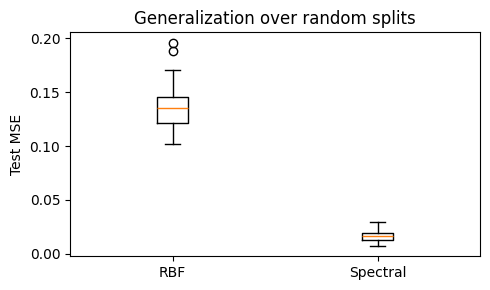

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import circulant
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.metrics import mean_squared_error

# 1. Create a regular grid and example spectral density
np.random.seed(0)
N = 100
x = np.linspace(0, 2 * np.pi, N, endpoint=False).reshape(-1, 1)
freqs = np.fft.fftfreq(N, d=(2 * np.pi) / N)
# example: Gaussian bump in spectrum
F = np.exp(-0.5 * ((freqs - 2.0) / 0.5) ** 2)

# Build Gram matrix via spectral kernel
k0 = np.fft.ifft(F).real
K = circulant(k0) + 1e-8 * np.eye(N)

# 2. Sample from prior
L = np.linalg.cholesky(K)
samples = L @ np.random.randn(N, 3)

# Plot Gram matrix
plt.figure(figsize=(5, 4))
plt.imshow(K, origin="lower", aspect="auto")
plt.title("Spectral Kernel Gram Matrix")
plt.xlabel("i"); plt.ylabel("j")
plt.tight_layout()
plt.show()

# Plot prior samples
plt.figure(figsize=(6, 3))
for i in range(3):
    plt.plot(x.ravel(), samples[:, i], label=f"sample {i+1}")
plt.title("Spectral GP Prior Samples")
plt.xlabel("x"); plt.legend()
plt.tight_layout()
plt.show()

# 3. Regression demo: compare RBF vs. spectral
noise = 0.1
f_true = samples[:, 0]
y = f_true + noise * np.random.randn(N)
idx = np.arange(N)
train_idx = idx[::5]
test_idx = np.setdiff1d(idx, train_idx)
X_train, y_train = x[train_idx], y[train_idx]
X_test = x[test_idx]

# a) RBF GP
gp_rbf = GaussianProcessRegressor(kernel=RBF(length_scale=1.0), alpha=noise**2, optimizer=None)
gp_rbf.fit(X_train, y_train)
y_rbf, std_rbf = gp_rbf.predict(X_test, return_std=True)

# b) Spectral GP closed-form
K_train = K[np.ix_(train_idx, train_idx)]
alpha = np.linalg.solve(K_train + noise**2 * np.eye(len(train_idx)), y_train)
K_test = K[np.ix_(test_idx, train_idx)]
y_spec = K_test @ alpha
v = np.linalg.solve(K_train, K_test.T)
post_cov_spec = K[np.ix_(test_idx, test_idx)] - K_test @ v
var_spec = np.diag(post_cov_spec)

# Plot regression results
plt.figure(figsize=(6, 3))
plt.plot(x, f_true, 'k--', label="True")
plt.scatter(X_train, y_train, c='tab:orange', marker='x', s=50, label="Train")
plt.plot(X_test, y_rbf, 'C0--', label="RBF GP")
plt.fill_between(X_test.ravel(), y_rbf - 2*std_rbf, y_rbf + 2*std_rbf, alpha=0.3)
plt.plot(X_test, y_spec, 'C2:', label="Spectral GP")
plt.fill_between(X_test.ravel(), y_spec - 2*np.sqrt(var_spec), y_spec + 2*np.sqrt(var_spec), alpha=0.3)
plt.legend(); plt.title("GP Regression: RBF vs. Spectral Kernel")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.tight_layout()
plt.show()

# 4. Periodogram vs spectrum
y_demean = y - y.mean()
Pxx = np.abs(np.fft.fft(y_demean))**2
plt.figure(figsize=(5, 3))
plt.plot(freqs, Pxx, label='Periodogram')
plt.plot(freqs, F, '--', label='Spectral weights')
plt.xlabel('frequency'); plt.ylabel('power')
plt.legend(); plt.title('Data Periodogram vs. Kernel Spectrum')
plt.tight_layout()
plt.show()

# 5. Eigenvalue decay
eigs_rbf = np.linalg.eigvalsh(gp_rbf.kernel_(x))
eigs_spec = np.linalg.eigvalsh(K)
plt.figure(figsize=(5, 3))
plt.loglog(np.sort(eigs_rbf)[::-1], label='RBF')
plt.loglog(np.sort(eigs_spec)[::-1], '--', label='Spectral')
plt.legend(); plt.title('Eigenvalue Decay of K')
plt.xlabel('index'); plt.ylabel('eigenvalue')
plt.tight_layout()
plt.show()

# 6. Posterior covariance heatmap (spectral GP)
plt.figure(figsize=(5, 4))
plt.imshow(post_cov_spec, origin='lower', aspect='auto')
plt.colorbar(); plt.title('Spectral GP Posterior Covariance (test grid)')
plt.tight_layout()
plt.show()

# 7. Out-of-sample generalization over random splits
mses_rbf, mses_spec = [], []
for seed in range(20):
    np.random.seed(seed)
    # random train/test 80/20
    perm = np.random.permutation(N)
    t = perm[:int(0.8*N)]
    s = perm[int(0.8*N):]
    Xtr, ytr = x[t], y[t]
    Xte, yte = x[s], y[s]

    # RBF
    gp = GaussianProcessRegressor(kernel=RBF(1.0), alpha=noise**2, optimizer=None)
    gp.fit(Xtr, ytr)
    yhat_rbf = gp.predict(Xte)
    mses_rbf.append(mean_squared_error(yte, yhat_rbf))

    # Spectral
    Ktr = K[np.ix_(t, t)]
    alpha_tr = np.linalg.solve(Ktr + noise**2*np.eye(len(t)), ytr)
    Kte = K[np.ix_(s, t)]
    yhat_spec = Kte @ alpha_tr
    mses_spec.append(mean_squared_error(yte, yhat_spec))

plt.figure(figsize=(5, 3))
plt.boxplot([mses_rbf, mses_spec], labels=['RBF','Spectral'])
plt.ylabel('Test MSE'); plt.title('Generalization over random splits')
plt.tight_layout()
plt.show()


## Numpyro Implementation

sample: 100%|██████████| 1500/1500 [04:16<00:00,  5.84it/s, 1023 steps of size 1.87e-03. acc. prob=0.92]


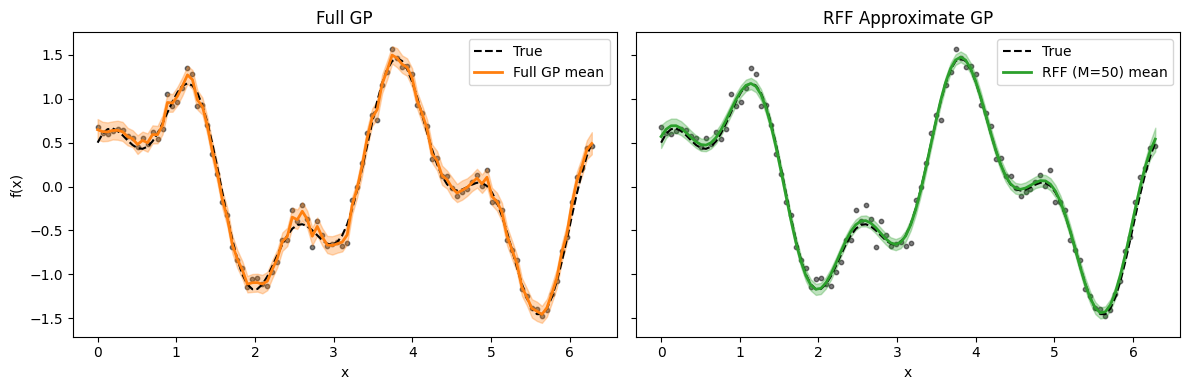

In [7]:
import numpy as np
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

# 1. Synthetic data
N = 100
x = np.linspace(0, 2 * np.pi, N)
f_true = np.sin(2.0 * x) + 0.5 * np.cos(5.0 * x)
noise_std = 0.1
y = f_true + noise_std * np.random.randn(N)

# 2a. Full GP model
def full_gp_model(x, y=None):
    ℓ   = numpyro.sample('ℓ',   dist.LogNormal(0.0, 0.5))
    amp = numpyro.sample('amp', dist.LogNormal(0.0, 0.5))
    σ   = numpyro.sample('σ',   dist.LogNormal(jnp.log(0.1), 0.2))

    dist_sq = (x[:, None] - x[None, :])**2
    K = amp**2 * jnp.exp(-0.5 * dist_sq / (ℓ**2))
    K += (σ**2 + 1e-6) * jnp.eye(N)

    f = numpyro.sample('f', dist.MultivariateNormal(jnp.zeros(N),
                                                   covariance_matrix=K))
    numpyro.sample('y', dist.Normal(f, σ), obs=y)

# 2b. RFF GP model
def rff_gp_model(x, y=None, M=50):
    ℓ   = numpyro.sample('ℓ',   dist.LogNormal(0.0, 0.5))
    amp = numpyro.sample('amp', dist.LogNormal(0.0, 0.5))
    σ   = numpyro.sample('σ',   dist.LogNormal(jnp.log(0.1), 0.2))

    W = numpyro.sample('W', dist.Normal(0.0, 1.0/ℓ).expand([M]))
    b = numpyro.sample('b', dist.Uniform(0.0, 2*np.pi).expand([M]))

    ϕ = amp * jnp.sqrt(2.0/M) * jnp.cos(jnp.outer(x, W) + b)
    a = numpyro.sample('a', dist.Normal(jnp.zeros(M), jnp.ones(M)))
    f = jnp.dot(ϕ, a)

    numpyro.deterministic('f', f)
    numpyro.sample('y', dist.Normal(f, σ), obs=y)

# 3. Inference
rng_key = random.PRNGKey(0)
# Full GP
mcmc_full = MCMC(NUTS(full_gp_model), num_warmup=500, num_samples=1000)
mcmc_full.run(rng_key, x=jnp.array(x), y=jnp.array(y))
samples_full = mcmc_full.get_samples()

# RFF GP (with fewer features to speed up; try M=50 or lower)
rng_key_rf = random.PRNGKey(1)
M_feats = 50
mcmc_rff = MCMC(NUTS(lambda x, y=None: rff_gp_model(x, y, M_feats)),
                num_warmup=500, num_samples=1000)
mcmc_rff.run(rng_key_rf, x=jnp.array(x), y=jnp.array(y))
samples_rff = mcmc_rff.get_samples()

# 4. Posterior predict latent f
post_full = Predictive(full_gp_model,
                       posterior_samples=samples_full,
                       return_sites=['f'],
                       parallel=True)(rng_key, x=jnp.array(x), y=None)['f']
post_full = np.array(post_full)

post_rff = Predictive(lambda x, y=None: rff_gp_model(x, y, M_feats),
                      posterior_samples=samples_rff,
                      return_sites=['f'],
                      parallel=True)(rng_key_rf, x=jnp.array(x), y=None)['f']
post_rff = np.array(post_rff)

# Summaries
mean_full = post_full.mean(0)
low_full,  high_full  = np.percentile(post_full, [2.5, 97.5], axis=0)
mean_rff  = post_rff.mean(0)
low_rff,   high_rff   = np.percentile(post_rff, [2.5, 97.5], axis=0)

# 5. Side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Full GP
ax1.plot(x, f_true,    'k--', label='True')
ax1.scatter(x, y, c='k', s=10, alpha=0.5)
ax1.plot(x, mean_full, 'C1', lw=2, label='Full GP mean')
ax1.fill_between(x, low_full, high_full, color='C1', alpha=0.3)
ax1.set_title('Full GP')
ax1.set_xlabel('x'); ax1.set_ylabel('f(x)')
ax1.legend()

# RFF GP
ax2.plot(x, f_true,   'k--', label='True')
ax2.scatter(x, y, c='k', s=10, alpha=0.5)
ax2.plot(x, mean_rff, 'C2', lw=2, label=f'RFF (M={M_feats}) mean')
ax2.fill_between(x, low_rff, high_rff, color='C2', alpha=0.3)
ax2.set_title('RFF Approximate GP')
ax2.set_xlabel('x')
ax2.legend()

plt.tight_layout()
plt.show()


## Function-Space vs. Weight-Space Views of Gaussian Processes

**1. Function-Space View**  
We place a prior directly on functions:
$$
f \sim \mathcal{GP}(0,\;k(\cdot,\cdot)),
$$
so that for any finite input set \(X=(x_1,\dots,x_N)\),
$$
[f(x_1),\dots,f(x_N)]^\top \sim \mathcal{N}\bigl(0,\,K\bigr),
$$
where $K_{ij}=k(x_i,x_j)$. No parameters or “weights” are introduced explicitly.

---

**2. Weight-Space View via Basis Expansion**  
Mercer’s theorem gives an expansion
$$
k(x,x') = \sum_{j=1}^\infty \lambda_j\,\phi_j(x)\,\phi_j(x'),
$$
so we can write
$$
f(x) = \sum_{j=1}^\infty w_j\,\phi_j(x),
\quad
w_j\sim\mathcal{N}(0,\lambda_j).
$$
Marginalizing out $\{w_j\}$ recovers exactly the same GP prior on $f$.

---

**3. Spectral/Circulant Case (DFT Basis)**  
On an equispaced grid wrapped to a circle, $K$ is circulant and diagonalized by the DFT:
$$
\mathbf{K} = \mathbf{F}^*\,\mathrm{diag}(F)\,\mathbf{F}.
$$
Equivalently,
$$
f = \sum_{\ell=0}^{N-1} w_\ell\,\phi_\ell,
\quad
w_\ell\sim\mathcal{N}(0,\,F_\ell),
$$
where $\phi_\ell(x_m)=e^{-2\pi i\,\ell m/N}$.  Marginalizing the $w_\ell$ yields the same multivariate normal on the $f(x_m)$.

---

**4. Why Use the Weight-Space (Spectral) View?**  
- **Computational Efficiency:**  Prior covariance on $w$ is diagonal ⇒ $\mathcal{O}(N\log N)$ inference.  
- **Interpretability:**  Direct inference on the spectrum $\{F_\ell\}$ and noise level, rather than kernel hyperparameters.

---

> **Bottom Line:**  
> Every GP admits both views—function-space (kernel-direct) or weight-space (basis-coefficients).  
> The circulant/DFT trick is just a choice of an orthonormal basis that makes inference fast, but it is an *exact* GP.  


sample: 100%|██████████| 1500/1500 [00:42<00:00, 35.41it/s, 511 steps of size 7.30e-03. acc. prob=0.96]


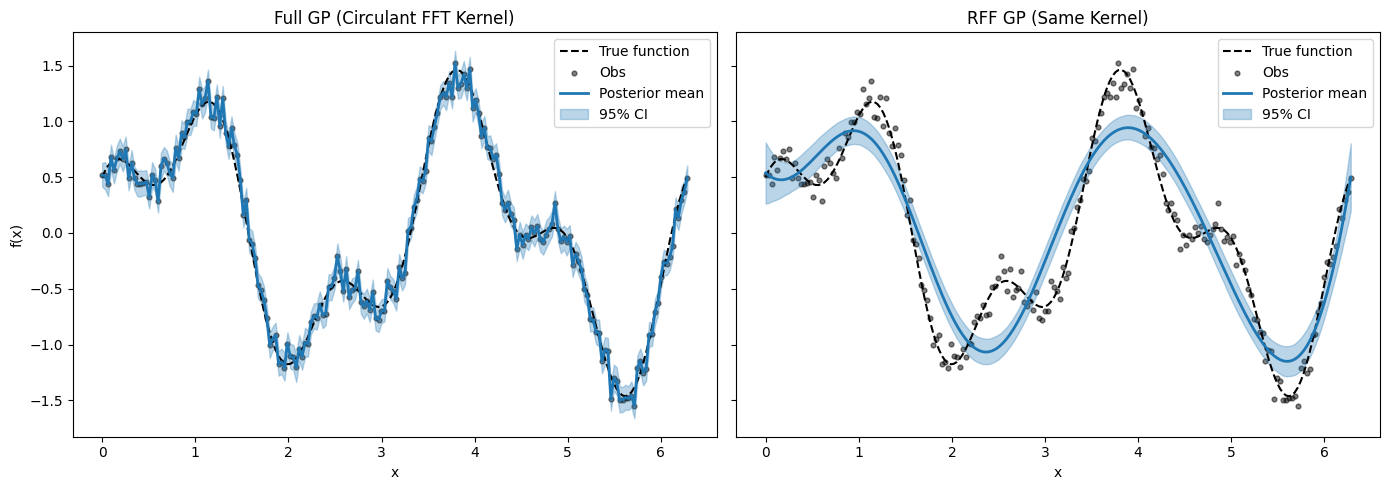

In [59]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

# ------------------------------------------------------
# 1) Full GP Model with CirculantNormal
# ------------------------------------------------------
def full_gp_spectral(x, y=None):
    n = x.shape[0]
    n_rfft = n // 2 + 1

    # 1a) Learn only the real-FFT bins
    θ = numpyro.sample("θ", dist.Normal(jnp.zeros(n_rfft), 1.0).to_event(1))
    F = jnp.log1p(jnp.exp(θ))                 # softplus → nonnegative spectrum

    # 1b) Observation noise
    σ_obs = numpyro.sample("σ_obs", dist.HalfNormal(0.2))

    # 1c) f ∼ N(0, C) where C is circulant with spectrum F
    f = numpyro.sample(
        "f",
        dist.CirculantNormal(loc=jnp.zeros(n), covariance_rfft=F)
    )

    # 1d) Likelihood
    numpyro.sample("y", dist.Normal(f, σ_obs), obs=y)


# ------------------------------------------------------
# 2) RFF Approximation, with W,b drawn once outside
# ------------------------------------------------------
def rff_gp_spectral(x, y=None, W=None, b=None, M=100):
    """
    x: [n] grid
    W: [M] fixed random frequencies
    b: [M] fixed random phases
    """
    # 2a) Hyperpriors
    ℓ   = numpyro.sample("ℓ",   dist.LogNormal(0.0, 0.5))
    amp = numpyro.sample("amp", dist.LogNormal(0.0, 0.5))
    σ   = numpyro.sample("σ",   dist.LogNormal(jnp.log(0.1), 0.2))

    # 2b) Build features φ(x) = amp * sqrt(2/M) cos(x W + b)
    ϕ = amp * jnp.sqrt(2.0 / M) * jnp.cos(jnp.outer(x, W) + b)

    # 2c) Bayesian linear model in RFF
    a = numpyro.sample("a", dist.Normal(jnp.zeros(M), jnp.ones(M)))
    f = jnp.dot(ϕ, a)

    numpyro.deterministic("f", f)
    numpyro.sample("y", dist.Normal(f, σ), obs=y)


# ------------------------------------------------------
# 3) Main: simulate data, run both models, and plot
# ------------------------------------------------------
def main():
    # — Synthetic data —
    N = 200
    x = np.linspace(0, 2*np.pi, N)
    f_true = np.sin(2.0 * x) + 0.5 * np.cos(5.0 * x)
    y = f_true + 0.1 * np.random.randn(N)

    x_j = jnp.array(x)
    y_j = jnp.array(y)

    # — Draw RFF frequencies ONCE from a “true” spectrum for approximation —
    # Here I’ll just use the spectrum of the true RBF+cos sum as an example,
    # but you could use the learned F from the full model if you like.
    # For simplicity, we’ll sample W ~ N(0,1) and b ~ Uniform(0,2π):
    M = 200
    key = jax.random.PRNGKey(42)
    key, k1, k2 = jax.random.split(key, 3)
    W = jax.random.normal(k1, (M,))               # e.g. approximate some underlying spectral shape
    b = 2*jnp.pi * jax.random.uniform(k2, (M,))

    # — 3.1 Full GP spectral —
    rng1 = jax.random.PRNGKey(0)
    mcmc1 = MCMC(NUTS(full_gp_spectral), num_warmup=500, num_samples=1000)
    mcmc1.run(rng1, x=x_j, y=y_j)
    post1 = mcmc1.get_samples()

    # — 3.2 RFF GP spectral —
    rng2 = jax.random.PRNGKey(1)
    mcmc2 = MCMC(NUTS(lambda x,y=None: rff_gp_spectral(x,y,W,b,M)),
                 num_warmup=500, num_samples=1000)
    mcmc2.run(rng2, x=x_j, y=y_j)
    post2 = mcmc2.get_samples()

    # — 4) Posterior predictive draws of f —
    pred1 = Predictive(full_gp_spectral,
                       posterior_samples=post1,
                       return_sites=["f"], parallel=True)
    f_samps1 = np.array(pred1(rng1, x=x_j, y=None)["f"])  # [S, N]

    pred2 = Predictive(lambda x,y=None: rff_gp_spectral(x,y,W,b,M),
                       posterior_samples=post2,
                       return_sites=["f"], parallel=True)
    f_samps2 = np.array(pred2(rng2, x=x_j, y=None)["f"])

    # — Summaries —
    mean1 = f_samps1.mean(0)
    lo1, hi1 = np.percentile(f_samps1, [2.5,97.5], axis=0)
    mean2 = f_samps2.mean(0)
    lo2, hi2 = np.percentile(f_samps2, [2.5,97.5], axis=0)

    # — 5) Plot side by side —
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5), sharey=True)
    for ax, mean, lo, hi, title in [
        (ax1, mean1, lo1, hi1, "Full GP (Circulant FFT Kernel)"),
        (ax2, mean2, lo2, hi2, "RFF GP (Same Kernel)"),
    ]:
        ax.plot(x, f_true,   'k--', label="True function")
        ax.scatter(x, y, c='k', s=12, alpha=0.5, label="Obs")
        ax.plot(x, mean, 'C0', lw=2, label="Posterior mean")
        ax.fill_between(x, lo, hi, color='C0', alpha=0.3, label="95% CI")
        ax.set_title(title)
        ax.set_xlabel("x")
        ax.legend()
    ax1.set_ylabel("f(x)")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


sample: 100%|██████████| 3000/3000 [00:01<00:00, 1735.64it/s, 47 steps of size 4.22e-01. acc. prob=0.86]


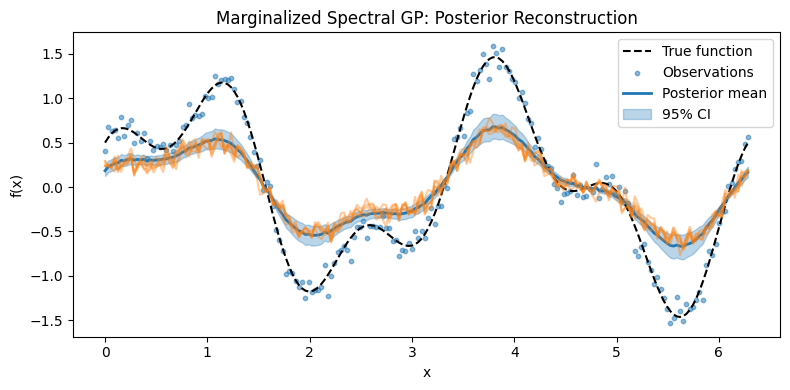

In [50]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

def marginalized_spectral_gp(y):
    """
    Marginalized GP prior with circulant covariance via its spectral density.
    Computes log marginal likelihood in O(N log N) using FFT.
    """
    n = y.shape[0]
    n_rfft = n // 2 + 1

    # 1) Prior on unconstrained log-spectrum parameters
    theta = numpyro.sample("theta", dist.Normal(jnp.zeros(n_rfft), 1.0).to_event(1))
    # Softplus → nonnegative spectral magnitudes
    F = jnp.log1p(jnp.exp(theta))

    # 2) Observation noise prior
    sigma = numpyro.sample("sigma", dist.HalfNormal(0.2))

    # 3) Log-determinant term: sum_j log(F_j + σ²)
    logdet = jnp.sum(jnp.log(F + sigma**2))

    # 4) Quadratic term via FFT:
    #    y_f = RFFT(y), then y^T (C+σ²I)⁻¹ y = sum_j |y_f_j|² / (F_j + σ²)
    y_f = jnp.fft.rfft(y - jnp.mean(y))
    quad = jnp.vdot(y_f / (F + sigma**2), y_f).real

    # 5) Log marginal likelihood factor
    log_lik = -0.5 * (quad + logdet + n * jnp.log(2 * jnp.pi))
    numpyro.factor("log_lik", log_lik)


def main():
    # — Synthetic data —
    N = 200
    x = np.linspace(0, 2 * np.pi, N)
    f_true = np.sin(2.0 * x) + 0.5 * np.cos(5.0 * x)
    y_obs = f_true + 0.1 * np.random.randn(N)

    # — Run MCMC on marginalized model —
    nuts = NUTS(marginalized_spectral_gp)
    mcmc = MCMC(nuts, num_warmup=1000, num_samples=2000)
    rng = jax.random.PRNGKey(0)
    mcmc.run(rng, y=jnp.array(y_obs))
    samples = mcmc.get_samples()
    thetas = samples["theta"]           # [S, n_rfft]
    sigmas = samples["sigma"]           # [S]

    # — Precompute FFT of demeaned data —
    y_dm = jnp.array(y_obs - y_obs.mean())
    Y_f = jnp.fft.rfft(y_dm)            # [n_rfft]

    # — Posterior mean reconstruction —
    # For each sample s:  F_s = softplus(theta_s)
    #   mean_f_freq = (F_s / (F_s + σ_s²)) * Y_f
    # then IRFFT → time domain
    def softplus(x): return jnp.log1p(jnp.exp(x))
    Fs = softplus(thetas)               # [S, n_rfft]
    denom = Fs + sigmas[:, None]**2     # [S, n_rfft]
    mean_f_freq = Fs * Y_f[None, :] / denom
    mean_time = jnp.fft.irfft(mean_f_freq, n=N)  # [S, N]

    # — Summaries: posterior mean & 95% CI —
    mu = np.mean(mean_time, axis=0)
    lo, hi = np.percentile(mean_time, [2.5, 97.5], axis=0)

    # — Sample posterior draws of f —
    # draw Z ~ N(0,1) in freq domain and add appropriate noise term
    key = jax.random.PRNGKey(1)
    n_samples = 5
    keys = jax.random.split(key, n_samples)
    def sample_f(theta, sigma, key):
        F = softplus(theta)
        y_f = Y_f
        mean_f = F * y_f / (F + sigma**2)
        var_f = (F * sigma**2) / (F + sigma**2)
        noise = jax.random.normal(key, shape=mean_f.shape) * jnp.sqrt(var_f)
        return jnp.fft.irfft(mean_f + noise, n=N)
    # pick a few posterior draws
    idxs = np.linspace(0, thetas.shape[0]-1, n_samples).astype(int)
    f_samps = [sample_f(thetas[i], sigmas[i], keys[i]) for i in idxs]

    # — Plot results —
    plt.figure(figsize=(8, 4))
    plt.plot(x, f_true, 'k--', label="True function")
    plt.scatter(x, y_obs, s=10, alpha=0.5, label="Observations")
    plt.plot(x, mu, 'C0', lw=2, label="Posterior mean")
    plt.fill_between(x, lo, hi, color='C0', alpha=0.3, label="95% CI")
    for fs in f_samps:
        plt.plot(x, np.array(fs), 'C1', alpha=0.4)
    plt.title("Marginalized Spectral GP: Posterior Reconstruction")
    plt.xlabel("x"); plt.ylabel("f(x)")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()



In [48]:
def binary_kl(q, p):
    first_term = 0.0 if q == 0 else q * np.log(q / p)
    second_term = 0.0 if q == 1 else (1 - q) * np.log((1 - q) / (1 - p))
    return first_term + second_term

k = 100
q = k/100 
p = 0.95
bound = binary_kl(q, p)
print(bound)

0.05129329438755048


sample: 100%|██████████| 1500/1500 [00:01<00:00, 1173.91it/s, 3 steps of size 4.80e-01. acc. prob=0.93]


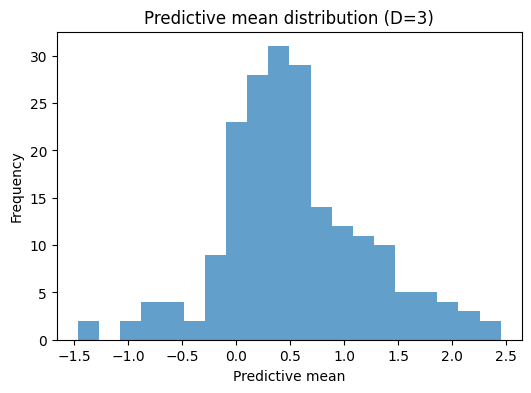

In [3]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import jax.scipy.linalg as linalg

# RBF kernel defined manually (supports D-dimensional inputs)
def rbf_kernel(X1, X2, variance, lengthscale):
    # X1: [n, d], X2: [m, d]
    sqdist = jnp.sum((X1[:, None, :] - X2[None, :, :])**2, axis=-1)
    return variance * jnp.exp(-0.5 * sqdist / (lengthscale**2))

# 1. Create synthetic data (supports arbitrary input dimension D)
def generate_data(key, n_train=20, dim=1):
    # Random inputs in [0, 10]^dim
    subkey, key = jax.random.split(key)
    X_train = jax.random.uniform(subkey, (n_train, dim), minval=0.0, maxval=10.0)
    # True function: sum of sines over each dimension
    f = jnp.sum(jnp.sin(X_train), axis=1)
    noise = 0.1 * jax.random.normal(key, (n_train,))
    y_train = f + noise
    return X_train, y_train

# 2. Define GP model manually
def model(X, y=None):
    # Priors on hyperparameters
    variance = numpyro.sample('kernel_variance', dist.LogNormal(0.0, 1.0))
    lengthscale = numpyro.sample('kernel_lengthscale', dist.LogNormal(0.0, 1.0))
    noise = numpyro.sample('obs_noise', dist.HalfCauchy(1.0))

    # Compute covariance matrix K + noise^2 I
    K = rbf_kernel(X, X, variance, lengthscale)
    K += (noise**2 + 1e-6) * jnp.eye(X.shape[0])

    # Zero-mean GP
    mean = jnp.zeros(X.shape[0])
    # Observations
    return numpyro.sample('y', dist.MultivariateNormal(mean, covariance_matrix=K), obs=y)

# 3. Run MCMC to infer hyperparameters
def infer_hyperparams(rng_key, X_train, y_train):
    nuts = NUTS(model)
    mcmc = MCMC(nuts, num_warmup=500, num_samples=1000)
    mcmc.run(rng_key, X_train, y_train)
    return mcmc.get_samples()

# 4. Posterior predictive manually
def predict(X_train, y_train, X_test, params):
    # Use posterior mean of hyperparameters
    var = jnp.mean(params['kernel_variance'])
    ls = jnp.mean(params['kernel_lengthscale'])
    noise = jnp.mean(params['obs_noise'])

    # Covariances
    K = rbf_kernel(X_train, X_train, var, ls) + (noise**2 + 1e-6) * jnp.eye(X_train.shape[0])
    K_s = rbf_kernel(X_train, X_test, var, ls)
    K_ss = rbf_kernel(X_test, X_test, var, ls) + 1e-6 * jnp.eye(X_test.shape[0])

    # Cholesky decomposition
    L = jnp.linalg.cholesky(K)
    # Solve for alpha: K^{-1} y
    alpha = linalg.cho_solve((L, True), y_train)
    mu_s = jnp.dot(K_s.T, alpha)

    # Predictive covariance
    v = linalg.solve_triangular(L, K_s, lower=True)
    cov_s = K_ss - jnp.dot(v.T, v)
    return mu_s, cov_s

# 5. Full workflow
if __name__ == '__main__':
    rng_key = jax.random.PRNGKey(0)
    # Data with dimension D (e.g., D=3)
    D = 3
    X_train, y_train = generate_data(rng_key, n_train=50, dim=D)
    # Generate test grid or random test points
    subkey, _ = jax.random.split(rng_key)
    X_test = jax.random.uniform(subkey, (200, D), minval=-1.0, maxval=11.0)

    # Inference
    params = infer_hyperparams(rng_key, X_train, y_train)

    # Prediction
    mean_pred, cov_pred = predict(X_train, y_train, X_test, params)
    std_pred = jnp.sqrt(jnp.diag(cov_pred))

    # Visualization note:
    # For D > 1, plotting is nontrivial. Here, we show a histogram of predictions.
    plt.figure(figsize=(6,4))
    plt.hist(mean_pred, bins=20, alpha=0.7)
    plt.title(f'Predictive mean distribution (D={D})')
    plt.xlabel('Predictive mean')
    plt.ylabel('Frequency')
    plt.show()

## Airline question:
Sampling i.i.d from a Bernoulli $ x \sim \sum_{i=1}^{N} \operatorname{Bernoulli}(p = 0.95) $, whats the upper bound on this event happening 100 consecutive times:
With $ p = \mathbb{E}[X] = 0.95 $ and the bad event being $\hat{p} - p = 0.05 $ we now have an epsilon to apply 

In [30]:
import numpy as np

def hoeffding(n, epsilon):
    return np.exp(-2*n*epsilon**2)

def kl_div(p_hat, q):
    q = np.clip(q, 1e-12, 1-1e-12)
    if p_hat == 0:
        first_term = 0.0
    else:
        first_term = p_hat * np.log(p_hat / q)
    if p_hat == 1:
        second_term = 0.0
    else:
        second_term = (1 - p_hat) * np.log((1 - p_hat) / (1 - q))
    return first_term + second_term

kl = kl_div(1, 0.95)
kl_bound = np.exp(-100*kl)
hoeffd = hoeffding(100, 0.05)
binomial = 0.95**100
print(f"Exact Binomial Tail: {binomial}")
print(f"Hoeffding Bound: {hoeffd}")
print(f"KL Bound: {kl_bound}")

Exact Binomial Tail: 0.0059205292203339975
Hoeffding Bound: 0.6065306597126333
KL Bound: 0.005920529220334054


## KL + binomial
$$
\underset{p \in [0,1]}{sup}\exp(-10000 KL(0.95|| p)p^{100}
$$

KL supremum: 0.006077314771520671
Optimal p:    0.95049


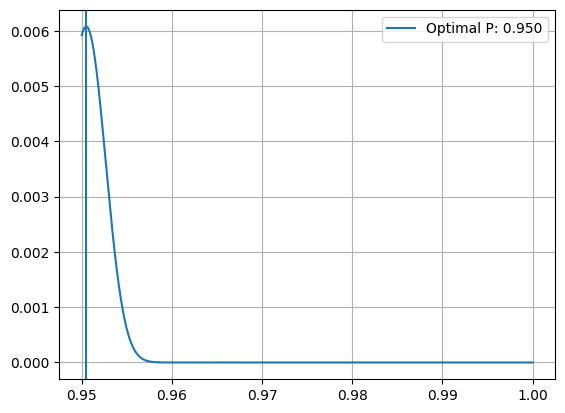

In [16]:
import numpy as np
import math

# Parameters
n1, n2 = 10_000, 100      # first‐stage and second‐stage sample sizes
q1 = 0.95                 # observed rate in stage 1

# KL‐divergence D(q||p)
def D(q, p):
    return q*math.log(q/p) + (1-q)*math.log((1-q)/(1-p))

# KL‐bound term for stage 1 and exact term for stage 2
def B_KL(p):
    return math.exp(-n1 * D(q1, p)) * (p**n2)

# Grid‐search on [q1, 1)
ps = np.linspace(q1, 1 - 1e-8, 20001)  # dense grid from 0.95 to (almost) 1
vals = np.array([B_KL(p) for p in ps])

# Find maximum
idx    = np.argmax(vals)
p_star = ps[idx]
B_star = vals[idx]

print(f"KL supremum: {B_star}")
print(f"Optimal p:    {p_star:.5f}")

plt.plot(ps, vals, label=f"")
plt.axvline(p_star, label=f"Optimal P: {p_star:.3f}")
plt.legend()
plt.grid(True)
plt.show()


## Hoeffding + binomial
$$
\underset{p \in [0,1]}{sup}\exp(-2*10000(p-0.95)^{2})p^{100}
$$

Final Bound: 0.006778


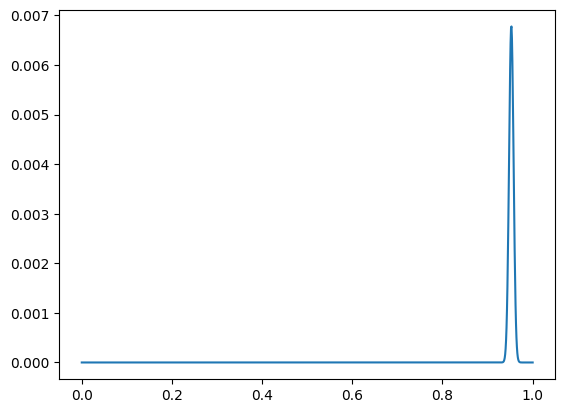

In [ ]:
# Assignment 2, a

import numpy as np
import matplotlib.pyplot as plt

def final(p):
    first = np.exp(-2*10000*(p-0.95)**2)
    second = p**100 
    return first * second 

p = np.linspace(0, 1, 1001)
bounds = final(p)
maxbound = np.max(bounds)
print(f"Final Bound: {maxbound:.4}")

plt.plot(p, bounds)
plt.show()

Exact bound: 0.000108 at p ≈ 0.9500


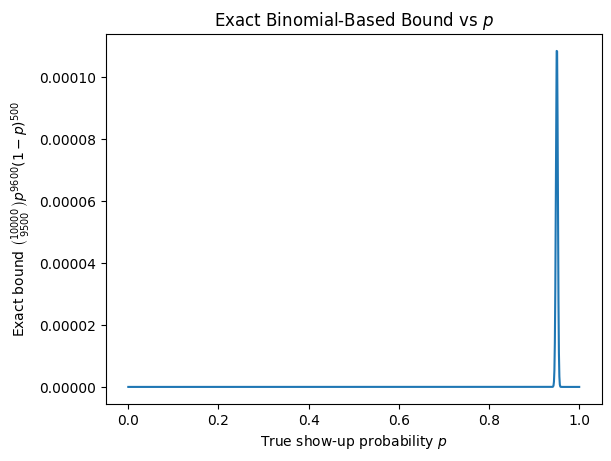

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Parameters
n = 10000          # first sample size
k1 = 9500          # successes in first sample
k2 = 100           # sample size for second stage
total_success = k1 + k2  # combined successes
fails = n - k1     # failures in first sample

# Pre-compute log of the binomial coefficient
log_binom = math.lgamma(n + 1) - math.lgamma(k1 + 1) - math.lgamma(n - k1 + 1)

def exact_bound(p):
    """Exact combined probability bound for given p."""
    return math.exp(log_binom + total_success * math.log(p) + fails * math.log(1 - p))

# Grid of p values avoiding 0 and 1
ps = np.linspace(1e-6, 1-1e-6, 1001)
bounds = np.array([exact_bound(p) for p in ps])

# Find the maximum bound
max_bound = np.max(bounds)
max_p = ps[np.argmax(bounds)]

# Display the results
print(f"Exact bound: {max_bound:.6f} at p ≈ {max_p:.4f}")

# Plotting
plt.plot(ps, bounds)
plt.xlabel("True show-up probability $p$")
plt.ylabel("Exact bound $\\binom{10000}{9500} p^{9600} (1-p)^{500}$")
plt.title("Exact Binomial-Based Bound vs $p$")
plt.show()


In [16]:
# Ghost-sample derivation for part (b)

n = 10000     # historical sample size
mh = 0.95     # observed show-up rate in historical sample
k = 100       # flight sample size
mf = 1.0      # observed show-up rate in flight sample

# Worst-case placement of p is the combined-sample proportion:
p_star = (n * mh + k * mf) / (n + k)

# Bound on P(flight all show up) under ghost-sample symmetrization:
bound_b = p_star ** k

print(f"Worst‑case p* = {p_star:.6f}")
print(f"Part (b) bound on P(event) ≈ {bound_b:.6f}")


Worst‑case p* = 0.950495
Part (b) bound on P(event) ≈ 0.006237
